# Reverse Distillation — Anomaly Detection (Holes / Lines / Stains)

This notebook trains a **Reverse Distillation (RD4AD)** model using [Anomalib](https://github.com/openvinotoolkit/anomalib).

**Important concept:** Reverse Distillation is trained ONLY on normal (`good`) images. It never sees defects during training — it learns what "normal features" look like, and at test time flags anything that deviates. Your defect folders (`holes`, `lines`, `stains`) are only used for **evaluation**, not training.

**Steps in this notebook:**
1. Setup & install
2. Mount Drive / upload dataset
3. Restructure dataset (create a proper `good`-only train set + a mixed normal+abnormal test set)
4. Build the Anomalib `Folder` datamodule
5. Train Reverse Distillation
6. Evaluate (AUROC, F1, etc.)
7. Visualize anomaly heatmaps
8. Export the trained model

## 1. Setup & install
Runtime → Change runtime type → **GPU** (T4 is fine) before running this.

In [ ]:
!pip install -q anomalib==2.0.0 lightning torchmetrics
!pip install -q timm einops FrEIA kornia

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.1/661.1 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.8/136.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 58.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 43.6 MB/s eta 0:00:00
CUDA available: True
Device: Tesla T4


## 2. Mount Google Drive and locate your dataset
Adjust `DATASET_ZIP` / `DATASET_DIR` to match where your data actually is.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# EDIT THESE PATHS
# DATASET_ZIP = "/content/drive/MyDrive/dataset.zip"   # set to your zip, or None if already unzipped
RAW_DATASET_DIR = "/content/drive/MyDrive/dataset/EfficientNetB0/dataset"              # where the original train/ test/ folders will live

os.makedirs(RAW_DATASET_DIR, exist_ok=True)

# if DATASET_ZIP and os.path.exists(DATASET_ZIP):
#     !unzip -q "$DATASET_ZIP" -d "$RAW_DATASET_DIR"
#     print("Unzipped to", RAW_DATASET_DIR)
# else:
#     print("No zip found at DATASET_ZIP — make sure RAW_DATASET_DIR already contains train/ and test/")

!find "$RAW_DATASET_DIR" -maxdepth 3 -type d

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/dataset/EfficientNetB0/dataset
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/train
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/train/good
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/test
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/test/holes
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/test/lines
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/test/stains
/content/drive/MyDrive/dataset/EfficientNetB0/dataset/test/good


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## 3. Restructure the dataset
Your original layout is:
```
train/  good (1400)  holes (1400)  lines (1400)  stains (1400)
test/          holes (300)   lines (300)   stains (300)
```
We rebuild it into what Reverse Distillation actually needs:
```
rd_dataset/
  good/        <- normal images used for TRAINING (most of train/good)
  test_good/   <- normal images held out for TESTING (a slice of train/good)
  holes/       <- ALL defect images (train+test holes) pooled, used only for TESTING
  lines/
  stains/
```
We hold out ~300 `good` images (matching your defect test-set size) so the test set is balanced between normal and each defect type.

In [ ]:
import shutil, random
from pathlib import Path

random.seed(42)

RAW = Path(RAW_DATASET_DIR)
OUT = Path("/content/rd_dataset")
if OUT.exists():
    shutil.rmtree(OUT)

N_TEST_GOOD = 300  # how many good images to hold out as normal test samples

defect_classes = ["holes", "lines", "stains"]

def list_images(folder):
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    return [p for p in folder.rglob("*") if p.suffix.lower() in exts]

# --- good images: split into train / held-out test ---
good_imgs = list_images(RAW / "train" / "good")
random.shuffle(good_imgs)
test_good_imgs = good_imgs[:N_TEST_GOOD]
train_good_imgs = good_imgs[N_TEST_GOOD:]

(OUT / "good").mkdir(parents=True, exist_ok=True)
(OUT / "test_good").mkdir(parents=True, exist_ok=True)

for p in train_good_imgs:
    shutil.copy(p, OUT / "good" / p.name)
for p in test_good_imgs:
    shutil.copy(p, OUT / "test_good" / p.name)

# --- defect images: pool train+test versions of each class together ---
for cls in defect_classes:
    dest = OUT / cls
    dest.mkdir(parents=True, exist_ok=True)
    for split in ["train", "test"]:
        src = RAW / split / cls
        if src.exists():
            for p in list_images(src):
                # avoid name collisions between the two source splits
                out_name = f"{split}_{p.name}"
                shutil.copy(p, dest / out_name)

print("Train good:", len(train_good_imgs))
print("Test good:", len(test_good_imgs))
for cls in defect_classes:
    print(f"{cls}:", len(list((OUT / cls).iterdir())))

Train good: 1100
Test good: 300
holes: 300
lines: 300
stains: 300


## 4. Build the Anomalib `Folder` datamodule

In [ ]:
from anomalib.data import Folder

datamodule = Folder(
    name="defects",
    root=OUT,
    normal_dir="good",
    abnormal_dir=defect_classes,        # ["holes", "lines", "stains"]
    normal_test_dir="test_good",
    train_batch_size=16,
    eval_batch_size=16,
    num_workers=4,
)

datamodule.setup()

print("Train samples:", len(datamodule.train_data))
print("Test samples:", len(datamodule.test_data))

batch = next(iter(datamodule.train_dataloader()))
print("Batch keys:", batch.__class__, batch.image.shape)

Train samples: 1100
Test samples: 600


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch keys: <class 'anomalib.data.dataclasses.torch.image.ImageBatch'> torch.Size([16, 3, 64, 64])


## 5. Define and train the Reverse Distillation model
Backbone `wide_resnet50_2` is the standard choice from the RD4AD paper. Training is unsupervised — only normal images are used in `fit()` even though the datamodule also holds defect images (those are only pulled in during `test()`).

In [ ]:
!pip uninstall -y openvino openvino-dev # Uninstall both to be sure
!pip install openvino # Install the latest available version
!pip install open_clip_torch

from anomalib.models import ReverseDistillation
from anomalib.engine import Engine

model = ReverseDistillation(
    backbone="wide_resnet50_2",
    layers=["layer1", "layer2", "layer3"],
)

engine = Engine(
    max_epochs=100,          # RD converges well within 100-200 epochs; reduce if you're time-limited
    accelerator="gpu",
    devices=1,
)

engine.fit(model=model, datamodule=datamodule)

  Using cached openvino-2026.2.1-21919-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (12 kB)
Using cached openvino-2026.2.1-21919-cp312-cp312-manylinux_2_28_x86_64.whl (58.4 MB)


INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor             │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor            │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator                │      0 │ train │     0 │
│ 3 │ model          │ ReverseDistillationModel │ 89.0 M │ train │     0 │
│ 4 │ loss           │ ReverseDistillationLoss  │      0 │ train │     0 │
└───┴────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 89.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 89.0 M                                                                                               
Total estimated model params size (MB): 356.009                                                                    
Modules in train mode: 347                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might 

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', 
..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`

Process Process-817:
Process Process-816:
Traceback (most recent call last):
INFO:lightning_fabric.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
Traceback (most recent call last):


  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 219, in _finalize_join
    thread.join()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._ca

RuntimeError: DataLoader worker (pid 46563) exited unexpectedly with exit code 1. Details are lost due to multiprocessing. Rerunning with num_workers=0 may give better error trace.

## 6. Evaluate on the test set (image-level AUROC / F1 / etc.)

In [ ]:
test_results = engine.test(model=model, datamodule=datamodule)
test_results

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec)

Output()

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric AUROC was called before the ``update`` method which may lead to errors, as metric states have not yet been 
updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric F1Score was called before the ``update`` method which may lead to errors, as metric states have not yet been
updated.
  warnings.warn(*args, **kwargs)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.7964370250701904     │
│       image_F1Score       │    0.8752556443214417     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.7964370250701904, 'image_F1Score': 0.8752556443214417}]

## 7. Visualize anomaly heatmaps on sample test images

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

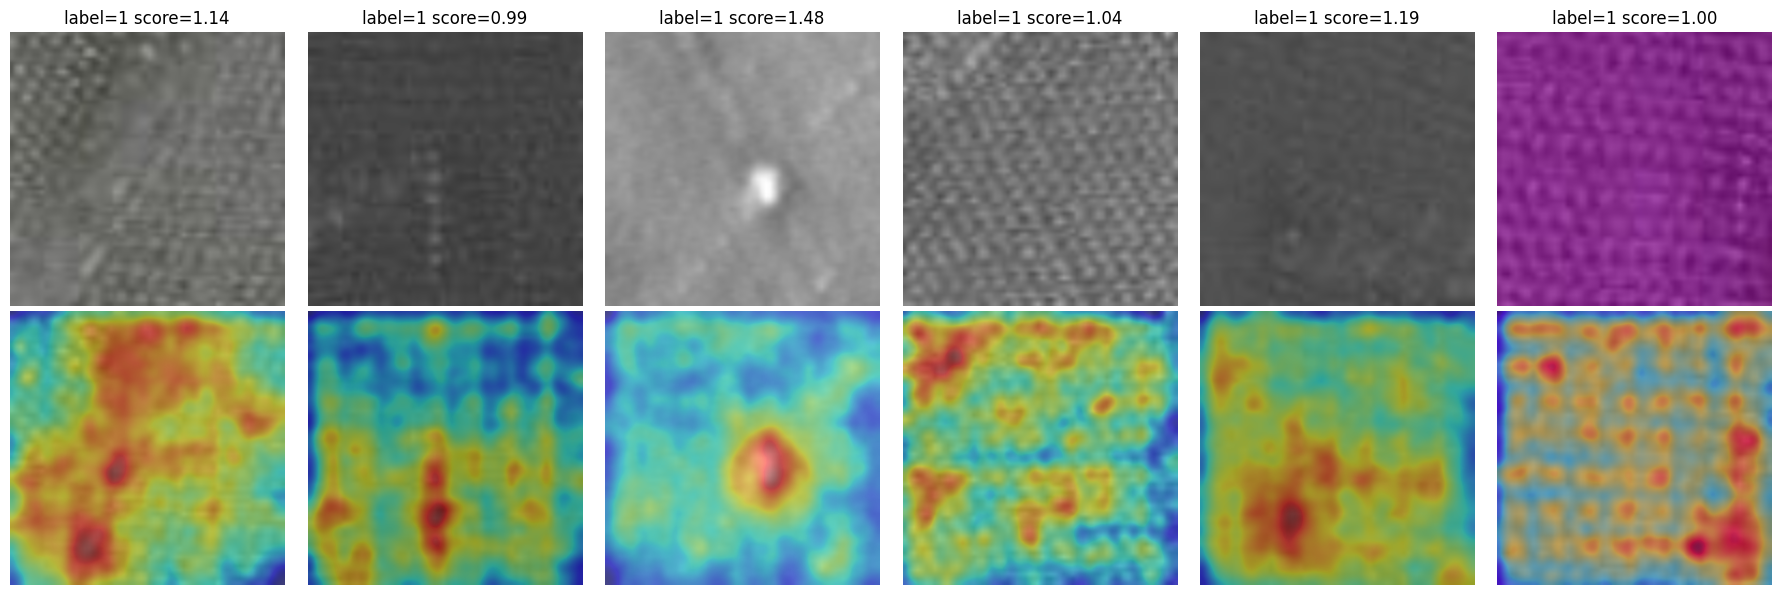

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

predictions = engine.predict(model=model, datamodule=datamodule)

# flatten predictions across batches
images, scores, labels, anomaly_maps = [], [], [], []
for batch in predictions:
    images.append(batch.image.cpu())
    scores.append(batch.pred_score.cpu())
    labels.append(batch.gt_label.cpu())
    anomaly_maps.append(batch.anomaly_map.cpu())

images = torch.cat(images)
scores = torch.cat(scores)
labels = torch.cat(labels)
anomaly_maps = torch.cat(anomaly_maps)

def denorm(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

n_show = 6
idxs = np.random.choice(len(images), size=n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for col, i in enumerate(idxs):
    axes[0, col].imshow(denorm(images[i]))
    axes[0, col].set_title(f"label={int(labels[i])} score={scores[i].item():.2f}")
    axes[0, col].axis("off")

    axes[1, col].imshow(denorm(images[i]))
    axes[1, col].imshow(anomaly_maps[i], cmap="jet", alpha=0.5)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## 8. Export the trained model (for reuse or deployment)

In [ ]:
export_dir = "/content/drive/MyDrive/reverse_distillation_export"
engine.export(model=model, export_type="torch", export_root=export_dir)
print("Model exported to:", export_dir)

## Notes / troubleshooting
- If `anomalib==2.0.0` fails to install cleanly, try `pip install anomalib` (latest) and drop the version pin — the API shown here matches the 2.x `Folder`/`Engine` interface.
- If you run out of GPU memory, drop `train_batch_size`/`eval_batch_size` to 8.
- If you have pixel-level defect masks, add a `mask_dir` to the `Folder(...)` call and Anomalib will also compute pixel-level AUROC/PRO and localize defects, not just classify images.
- Since your defect folders weren't originally meant for training, all defect images here are used purely for testing/threshold calibration — this is expected and correct for an unsupervised method like Reverse Distillation.